# Análise: A Armadilha da Zona Cinzenta (Z3)
### Por que atletas recreativos acumulam fadiga mesmo treinando consistentemente?
**Autor:** Guilherme  
**Data:** Abril/2026  
**Dataset:** Fitbit Public Dataset (Kaggle)

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.chdir(r'c:\projetosprojeto-suplementacao')

BASE = 'data/raw/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16'

df = pd.read_csv(f'{BASE}/dailyActivity_merged.csv')
print(f"Dataset carregado: {df.shape[0]} registros, {df['Id'].nunique()} usuários")
df.head()

Dataset carregado: 457 registros, 35 usuários


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


## Etapa 1 — Classificação de Zonas de Treino
Criamos uma variável nova classificando cada dia pelo tipo de intensidade predominante,
baseada nos minutos em cada nível de atividade registrados pelo Fitbit.

In [31]:
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])

def classificar_zona(row):
    if row['VeryActiveMinutes'] > 30:
        return 'Z4-Z5 (Alta)'
    elif row['FairlyActiveMinutes'] > 30:
        return 'Z3 (Moderada)'
    else:
        return 'Z1-Z2 (Baixa)'

df['zona_predominante'] = df.apply(classificar_zona, axis=1)

print("Distribuição de zonas:")
print(df['zona_predominante'].value_counts())
print("\nProporção:")
print(df['zona_predominante'].value_counts(normalize=True).mul(100).round(1))

Distribuição de zonas:
zona_predominante
Z1-Z2 (Baixa)    326
Z4-Z5 (Alta)      95
Z3 (Moderada)     36
Name: count, dtype: int64

Proporção:
zona_predominante
Z1-Z2 (Baixa)    71.3
Z4-Z5 (Alta)     20.8
Z3 (Moderada)     7.9
Name: proportion, dtype: float64


## Etapa 2 — Cruzamento com Dados de Sono
Carregamos os registros de sono minuto a minuto e agregamos por dia,
depois cruzamos com as zonas de treino para comparar a recuperação.

In [33]:
df_sleep = pd.read_csv(f'{BASE}/minuteSleep_merged.csv')

df_sleep['date'] = pd.to_datetime(df_sleep['date'])
df_sleep['ActivityDate'] = df_sleep['date'].dt.normalize()

sono_diario = df_sleep[df_sleep['value'] == 1].groupby(
    ['Id', 'ActivityDate']
).size().reset_index(name='minutos_dormindo')

sono_diario['horas_sono'] = (sono_diario['minutos_dormindo'] / 60).round(2)

df_merged = pd.merge(df, sono_diario, on=['Id', 'ActivityDate'], how='inner')

print("=== MÉDIA DE SONO POR ZONA ===")
print(df_merged.groupby('zona_predominante')['horas_sono'].mean().round(2))
print("\n=== MÉDIA DE CALORIAS POR ZONA ===")
print(df_merged.groupby('zona_predominante')['Calories'].mean().round(0))

=== MÉDIA DE SONO POR ZONA ===
zona_predominante
Z1-Z2 (Baixa)    6.87
Z3 (Moderada)    6.19
Z4-Z5 (Alta)     6.08
Name: horas_sono, dtype: float64

=== MÉDIA DE CALORIAS POR ZONA ===
zona_predominante
Z1-Z2 (Baixa)    2190.0
Z3 (Moderada)    2361.0
Z4-Z5 (Alta)     2648.0
Name: Calories, dtype: float64


## Etapa 3 — Frequência Cardíaca por Zona
A FC média diária indica eficiência cardiovascular — 
corações mais condicionados trabalham com menos batimentos para o mesmo esforço.

In [34]:
df_hr = pd.read_csv(f'{BASE}/heartrate_seconds_merged.csv')

df_hr['Time'] = pd.to_datetime(df_hr['Time'])
df_hr['ActivityDate'] = df_hr['Time'].dt.normalize()

fc_diaria = df_hr.groupby(['Id', 'ActivityDate'])['Value'].mean().reset_index()
fc_diaria.columns = ['Id', 'ActivityDate', 'fc_media']

df_merged2 = pd.merge(df_merged, fc_diaria, on=['Id', 'ActivityDate'], how='inner')

print("=== FC MÉDIA POR ZONA ===")
print(df_merged2.groupby('zona_predominante')['fc_media'].mean().round(1))

=== FC MÉDIA POR ZONA ===
zona_predominante
Z1-Z2 (Baixa)    75.7
Z3 (Moderada)    80.1
Z4-Z5 (Alta)     75.4
Name: fc_media, dtype: float64


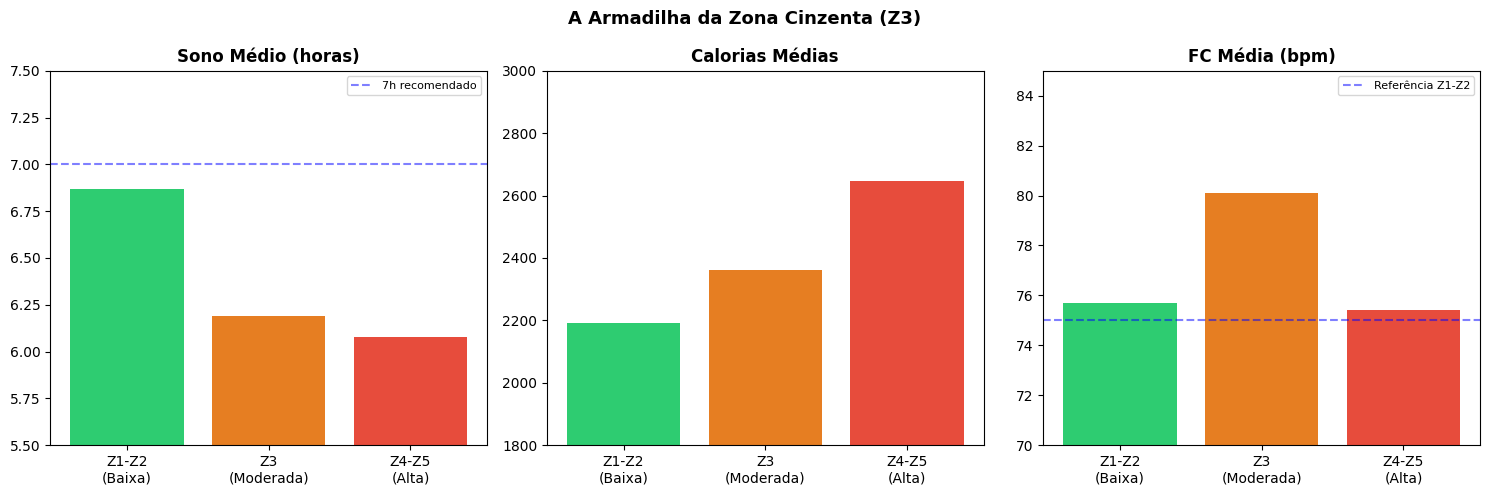

Gráfico salvo!


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

zonas = ['Z1-Z2\n(Baixa)', 'Z3\n(Moderada)', 'Z4-Z5\n(Alta)']
cores = ['#2ecc71', '#e67e22', '#e74c3c']

axes[0].bar(zonas, [6.87, 6.19, 6.08], color=cores)
axes[0].set_title('Sono Médio (horas)', fontweight='bold')
axes[0].set_ylim(5.5, 7.5)
axes[0].axhline(y=7, color='blue', linestyle='--', alpha=0.5, label='7h recomendado')
axes[0].legend(fontsize=8)

axes[1].bar(zonas, [2190, 2361, 2648], color=cores)
axes[1].set_title('Calorias Médias', fontweight='bold')
axes[1].set_ylim(1800, 3000)

axes[2].bar(zonas, [75.7, 80.1, 75.4], color=cores)
axes[2].set_title('FC Média (bpm)', fontweight='bold')
axes[2].set_ylim(70, 85)
axes[2].axhline(y=75, color='blue', linestyle='--', alpha=0.5, label='Referência Z1-Z2')
axes[2].legend(fontsize=8)

plt.suptitle('A Armadilha da Zona Cinzenta (Z3)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/graficos/analise_final_zonas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo!")

## Conclusão

| Indicador | Z1-Z2 (Baixa) | Z3 (Moderada) | Z4-Z5 (Alta) |
|-----------|--------------|--------------|--------------|
| Sono médio | 6.87h | 6.19h ⚠️ | 6.08h |
| Calorias médias | 2190 | 2361 | 2648 |
| FC média | 75.7 bpm | 80.1 bpm ⚠️ | 75.4 bpm |

### Insights

1. **Z3 tem a pior relação esforço/recuperação** — dorme menos que Z1-Z2 
sem atingir o condicionamento de Z4-Z5.

2. **FC mais alta em Z3 do que em Z4-Z5** — indica menor eficiência 
cardiovascular, característica de acúmulo de fadiga sem periodização.

3. **Nenhuma zona atinge 7h de sono recomendadas.**

### Limitações
- Dataset de 2016, 30 usuários — amostra pequena
- Sem dados diretos de suplementação ou hidratação
- FC média diária não separa repouso de treino